# Projeto Final de Modelos Avançados

**Objetivo do Projeto:**

O objetivo deste projeto é realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means, além de técnicas de exploração de dados, pré-processamento, implementação e avaliação de modelos.

Nossa variável alvo será a "Spending Score", uma nota de 1 a 100 que indica o comportamento de gastos do cliente.

In [131]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from plotly.subplots import make_subplots

## Análise Exploratória dos Dados
### Análise Exploratória - Geral


In [132]:
df = pd.read_csv("Mall_Customers.csv", delimiter=',')
df_original = df.copy()
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


Como mostram os dados acima e abaixo, a base possui  colunas, como o esperado, e 200 linhas. O número de dados é pequeno, o que pode resultar em um modelo que não captura a diversidade e nuances do público. É possível que, pela amostra ser pequena, os dados estejam desbalanceados em função da forma pela qual os dados foram obtidos. Por exemplo, cadastro via uma promoção, obtidos em lojas específicas, cadastro do estacionamento, etc.    

Os dados não possuem valores nulos, todos os tipos de dados estão adequados para sua variável e não há erros de digitação na variável categórica.
Há apenas uma variável categórica que pode ser posteriormente adaptada para análise numérica. 
A coluna com o ID do cliente não é do nosso interesse, então pode ser excluída.

In [133]:
df.drop(['CustomerID'],axis = 1, inplace=True)
df.head(2)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81


In [134]:
print(f"Dimensões da base {df.shape}\n")
print("Verificando o tipo de dados das colunas:\n")
df.info()
print("\nVerificando valores nulos na base de dados:\n")
print(df.isnull().sum())
print("\nVerificando valores únicos nas colunas categóricas:\n")

for coluna in df:
    if df[coluna].dtype != 'int64' and df[coluna].dtype != 'float64':
        print(df[coluna].unique())



Dimensões da base (200, 4)

Verificando o tipo de dados das colunas:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB

Verificando valores nulos na base de dados:

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Verificando valores únicos nas colunas categóricas:

['Male' 'Female']


In [135]:

print("\nVerificando estatísticas descritivas da base de dados:\n")
df.describe()


Verificando estatísticas descritivas da base de dados:



,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Na análise estatística, as variáveis idade e nota de gasto apresentam o comportamento esperado. Já a variável de Receita Anual apresenta um valor máximo estranho, indicando que será necessário investigar por possíveis outliers ou por um  desbalancemanto.

Os valores de todas as variáveis são da mesma ordem de grandeza, dispensando a necessidade de padronização ou normalização.


### Análise Exploratória - Variáveis Categóricas


Na pré-avaliação da distribuição das variáveis em relação a variável categórica, a distribição apresenta um comportamento adequado, indicando que os dados estão saudáveis. 

Já é possível identificar que, apesar do grupo de gênero masculino ser proporcionalmente menor, sua receita e gastos é superior à do gênero feminino, comportamento esse de acordo com o geralmente identificado entre essas populações.

In [136]:

for coluna in df:
    if df[coluna].dtype != 'int64' and df[coluna].dtype != 'float64':
        for categoria in df[coluna].unique():
            print(f"A coluna {coluna} possui {df[df[coluna] == categoria].shape[0]} registros na categoria {categoria}")


categoria = 'Gender'
contagem_categoria = df[categoria].value_counts(normalize=True).reset_index()
print(f"\n {contagem_categoria}\n")
for coluna in df:
    if coluna != categoria:
        
        media_categoria = df.groupby(categoria)[coluna].mean().reset_index().sort_values(by=coluna, ascending=False)
        desvio_padrao_categoria = df.groupby(categoria)[coluna].std().reset_index()
        print(f"\n{media_categoria}")



A coluna Gender possui 88 registros na categoria Male
A coluna Gender possui 112 registros na categoria Female

    Gender  proportion
0  Female        0.56
1    Male        0.44


   Gender        Age
1    Male  39.806818
0  Female  38.098214

   Gender  Annual Income (k$)
1    Male           62.227273
0  Female           59.250000

   Gender  Spending Score (1-100)
0  Female               51.526786
1    Male               48.511364


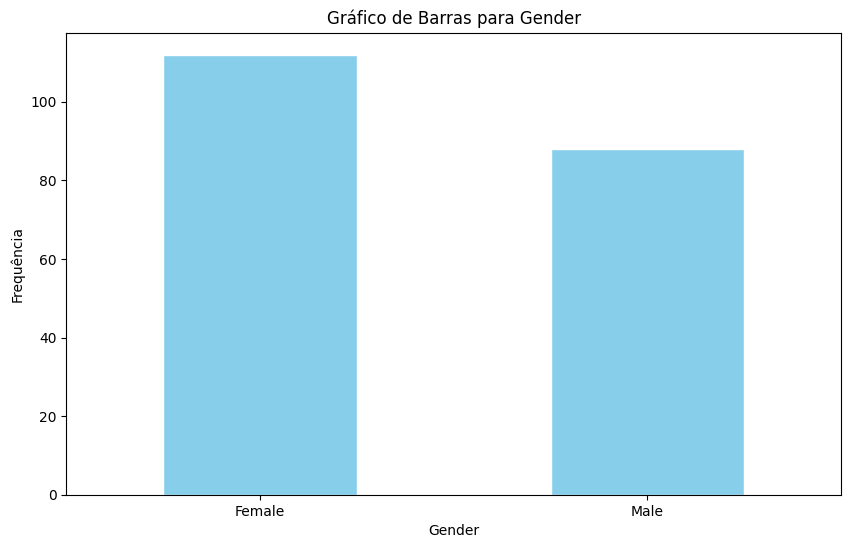

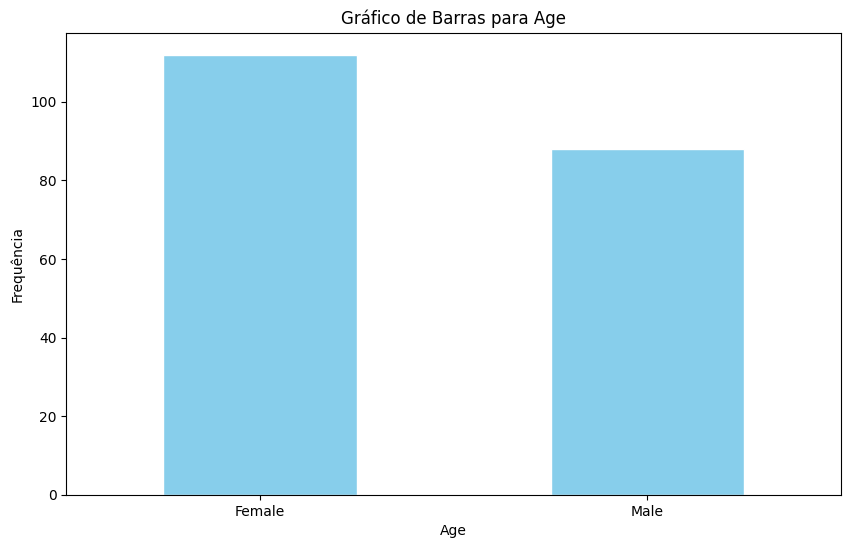

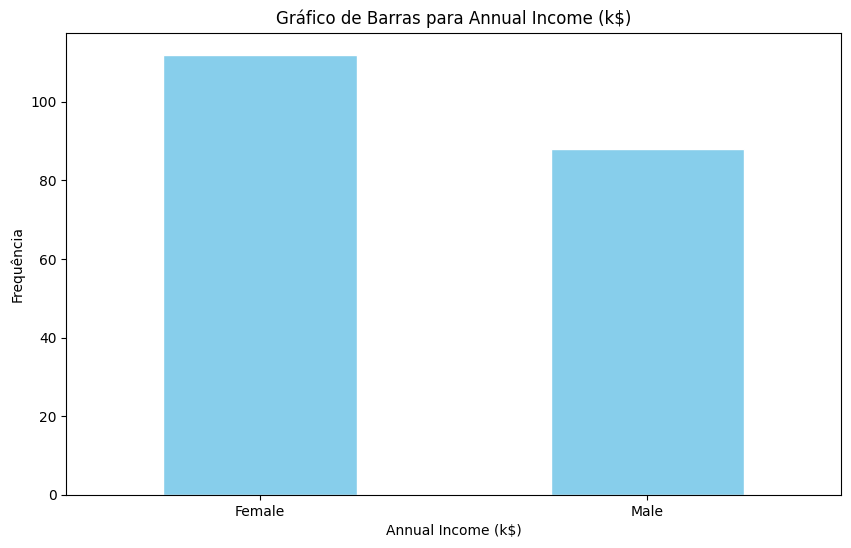

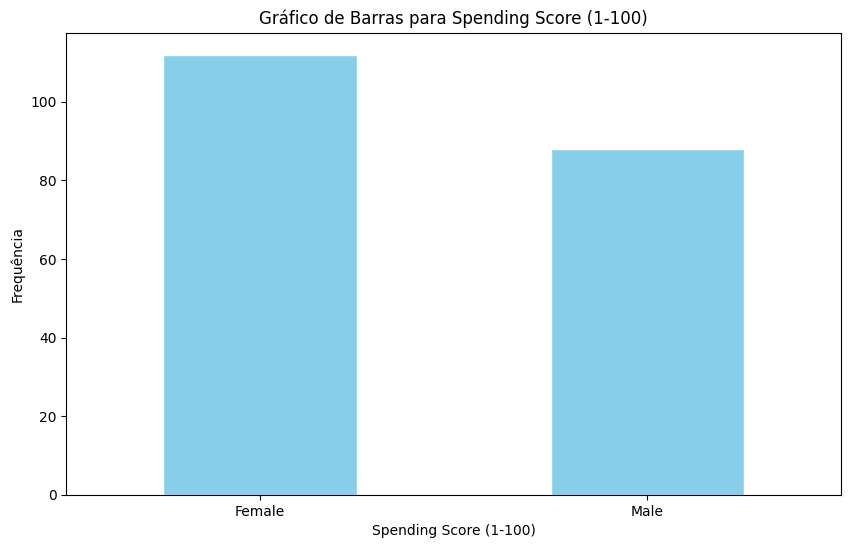

In [137]:
for campo in df:
    if df[campo].nunique() <= 10:  # Verifica se o campo é categórico
        contagem = df[campo].value_counts() 
    porcentagem = (contagem / contagem.sum()) * 100
    ax = contagem.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='white')
    plt.title(f'Gráfico de Barras para {campo}')
    plt.xticks(rotation=0)
    plt.xlabel(f'{campo}')
    plt.ylabel('Frequência')
    plt.show()

plt.close('all')


### Análise Exploratória - Possíveis Agrupamentos

Ao analisar os gráficos de distribuição das variáveis, o único agrupamento que se destaca, visualmente, é o da relação entre nota de gastos e receita anual. O gráfico mostra pelo menos 5 grupos. Esse valor pode ser usado para determinar o número de clusters do modelo.

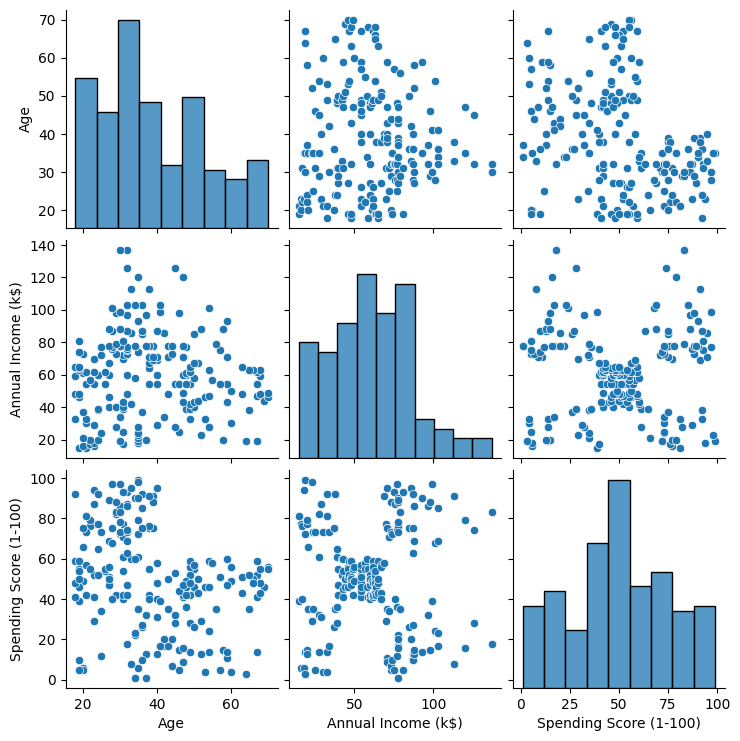

In [138]:
sns.pairplot(df)
plt.show()

## Tratamento de Dados

A partir da análise exploratória do item anterior, a única ação necessária, além do tratamento de outliers, é a transformação das variáveis categóricas em numéricas.

In [139]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])
df.drop(['Gender'], axis = 1, inplace=True)
df.head(5)

,Age,Annual Income (k$),Spending Score (1-100),Gender_encoded
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


### Análise de Outliers

A anáslise estatística comentada anteriormente indicou a possibilidade de outlier na variável de receita anual (Annual Income). Para aprofundar esta análise, seguem abaixo a distribuição dos dados.

O histograma do campo indica quatro valores que se destacam dos outros, mas apenas um está acima do "upper bound", o limite superior do IQR. O box plot também indica apenas um valor superior.

Pela simplicidade, optou-se por excluir este valor.  

In [140]:
campo = 'Annual Income (k$)'

#$ IQR
q1 = df[campo].quantile(0.25)
q3 = df[campo].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

fig = make_subplots(rows=1, cols=2, subplot_titles=[f'Histograma de {campo}', f'Box Plot de {campo}'])
fig.add_trace(
    px.histogram(df, x=campo, histnorm="percent", nbins=100).data[0],
    row=1, col=1
    )
fig.add_vline(x=upper_bound, line_dash="dash", line_color="red", row=1, col=1)
fig.add_trace(
    px.box(df, y=campo).data[0],
    row=1, col=2
    )
fig.add_hline(y=upper_bound, line_dash="dash", line_color="red", row=1, col=2)
fig.update_layout(title_text=f'{campo}', showlegend=False)
fig.show()
    

In [141]:
df = df[df['Annual Income (k$)'] < upper_bound]
print(df.shape)

(198, 4)


## Balanceamento - Distribuição da Variável Alvo

O gráfico abaixo mostra a distribuição dos dados por nota. O comportamento em escada mostra um padrão desbalanceado, com muitos dados para as notas mais baixas, e menos dados para notas mais altas. Além disso, já é possível identificar possíveis grupos para nosso modelo de classificação, já que os dados parecem estar bem separados por grupos de notas.

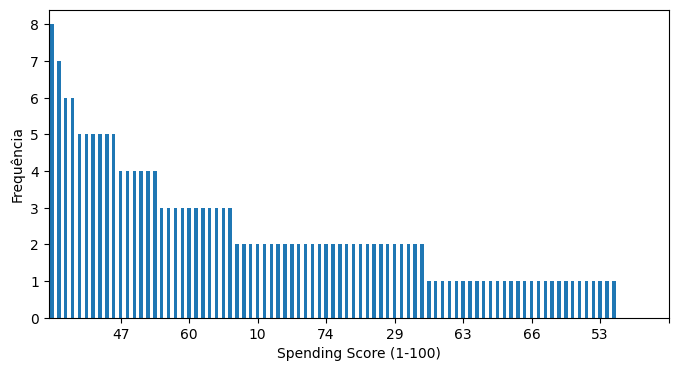

In [142]:
alvo_y = 'Spending Score (1-100)'
contagem_alvo = df[alvo_y].value_counts()
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel(alvo_y)
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)

plt.show()

### Corrigir balanceamento

Para a correção do balanceamento, optei por usar a técnica SMOTE, que promove o oversampling criando exemplos sintéticos da classe minoritária. Optei por aplicar essa estratégia por entender que ela balanceia os dados sem mudar a distribuição da população em relação a variável alvo. Ela se baseia na interpolação entre exemplos existentes da classe minoritária. 

Contudo, para funcionar, é preciso que todas as classes da variável y, Spending Score, tenham pelo menos duas amostras. Como é possível ver no histograma exibido anteriormente, isso não ocorre. Para driblar essa limitação, as notas serão agrupadas 

*Por esses motivos, sugiro que dois modelos sejam avaliados: um com os dados balanceados, outro como os dados originais.*

In [143]:
df_ampliado = pd.concat([df, df], ignore_index=True)
df_ampliado.shape

(396, 4)

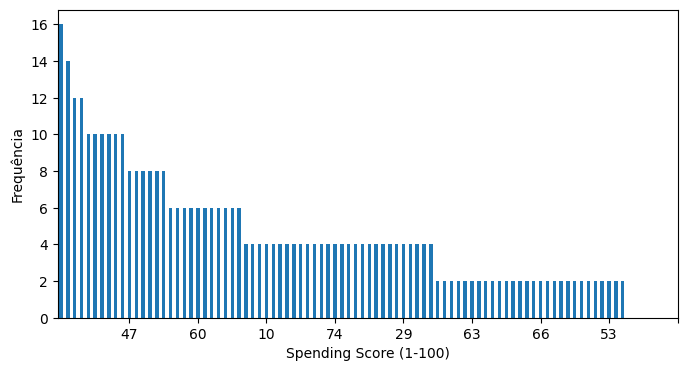

In [144]:
contagem_alvo = df_ampliado[alvo_y].value_counts()
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel(alvo_y)
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)
plt.show()

**Ao duplicar o df foi obtido um novo data frame com as cadacterísticas adequadas, sem, com isso, alterar a distribuição dos dados. Agora é possível aplicar o SMOTE.**

In [147]:
from imblearn.over_sampling import SMOTE
alvo_y = 'Spending Score (1-100)'
x = df_ampliado.drop(alvo_y, axis=1)
y = df_ampliado[alvo_y]
# Verifique o índice da coluna categórica
gender_idx = x.columns.get_loc('Gender_encoded')
print('Índice da coluna categórica:', gender_idx)
smote_nc = SMOTENC(categorical_features=[gender_idx], random_state=42, k_neighbors=1)
xb, yb = smote_nc.fit_resample(x, y)

Índice da coluna categórica: 2


In [148]:
smote = SMOTE(random_state=42, k_neighbors=1)
dxb, dyb = smote.fit_resample(x,y)

**Como é possível verificar abaixo, os dados foram equilibrados.**

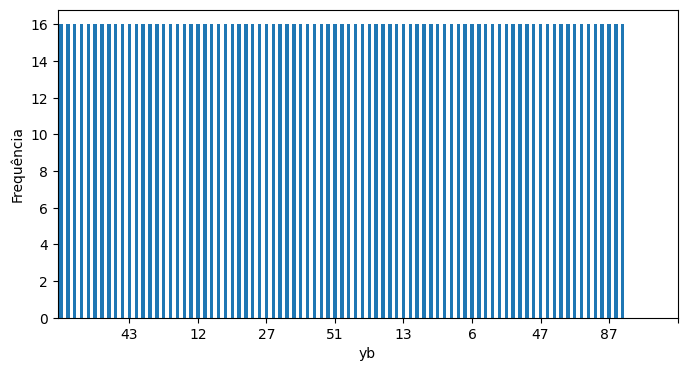

In [149]:
contagem_alvo = dyb.value_counts()
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel("yb")
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)
plt.show()

**Para melhor performance do modelo, optou-se por padronizar os dados.**

In [150]:
from sklearn.preprocessing import StandardScaler
colunas_padronizar = dxb.columns
scaler = StandardScaler()
dxb[colunas_padronizar] = scaler.fit_transform(dxb[colunas_padronizar])

# Converter xb para DataFrame com nomes corretos


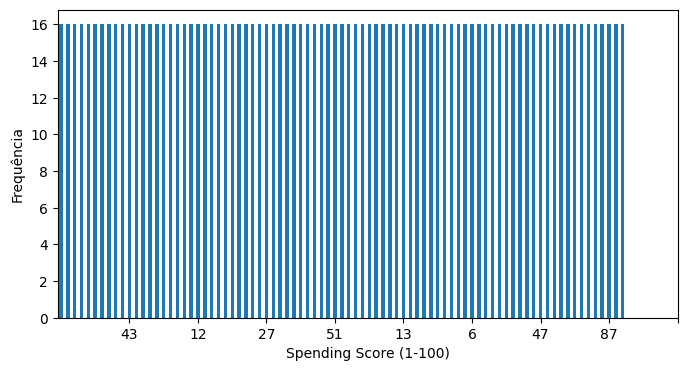

In [152]:
target_name = 'Spending Score (1-100)'
xb_df = pd.DataFrame(xb, columns=x.columns)
yb_s = pd.Series(yb, name=target_name)
df_balanciado = pd.concat([xb_df, yb_s], axis=1)
df_balanciado.head(10)
contagem_alvo = yb_s.value_counts()
plt.figure(figsize=(8, 4))
ax = contagem_alvo.plot(kind='bar')
ax.set_xlabel(target_name)
ax.set_ylabel('Frequência')
plt.xticks(ticks=range(10,100,10),rotation=0)
plt.show()

In [153]:
# Implementação do KMeans e plotagem dos clusters e centroides
from sklearn.cluster import KMeans
colunas_features = ['Annual Income (k$)', 'Spending Score (1-100)', 'Gender_encoded']
X_kmeans = df_padrao[colunas_features]
kmeans_perfil = KMeans(n_clusters=5, n_init=10, random_state=42)
kmeans_perfil.fit(X_kmeans)
centroides = kmeans_perfil.cluster_centers_
centroides_originais = scaler.inverse_transform(centroides)
labels = kmeans_perfil.labels_
clusters = df_balanciado.copy()
clusters['cluster'] = labels.astype(str)
import plotly.express as px
import plotly.graph_objects as go
fig = px.scatter(clusters, x='Annual Income (k$)', y='Spending Score (1-100)', color='cluster', color_discrete_sequence=px.colors.qualitative.Plotly, opacity=0.7, title='Clusters')
fig.add_scatter(x=centroides_originais[:, 0], y=centroides_originais[:, 1], mode='markers', marker=dict(color='black', symbol='x', size=14), name='Centroides')
fig.update_layout(xaxis_title='Annual Income (k$)', yaxis_title='Spending Score (1-100)', legend_title='Cluster')
fig.show()

# Deu errado, voltar para tratamento de dados e avaliar.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.